In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import copy
import json
from scipy.stats import ttest_ind, mannwhitneyu, normaltest
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

In [22]:
with open("epilepsy_summaries.json", "r") as f:
    epilepsy_summaries = json.load(f)

with open("control_summaries.json", "r") as f:
    control_summaries = json.load(f)

print(len(epilepsy_summaries))
print(len(control_summaries))

electrode_results = epilepsy_summaries + control_summaries

1361
257


In [23]:
with open("pid_epilepsy_summaries.json", "r") as f:
    pid_epilepsy_summaries = json.load(f)

with open("pid_control_summaries.json", "r") as f:
    pid_control_summaries = json.load(f)

print(len(pid_epilepsy_summaries))
print(len(pid_control_summaries))

pid_electrode_results = pid_epilepsy_summaries + pid_control_summaries

1361
257


In [24]:
print(type(epilepsy_summaries[0]))
print(list(epilepsy_summaries[0].keys()))  # electrode names
print(list(epilepsy_summaries[0]['T3'].keys()))  # measure names for one electrode

<class 'dict'>
['FP1', 'FP2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'FZ', 'CZ', 'PZ']
['optimal_p', 'delta_eeg_to_hrv', 'hrv_to_delta_eeg', 'delta_eeg_to_lf', 'lf_to_delta_eeg', 'delta_eeg_to_hf', 'hf_to_delta_eeg', 'alpha_eeg_to_hrv', 'hrv_to_alpha_eeg', 'alpha_eeg_to_lf', 'lf_to_alpha_eeg', 'alpha_eeg_to_hf', 'hf_to_alpha_eeg']


In [25]:
def flatten_electrode_results(electrode_results, agg='mean'):
    """
    Convert per-electrode results to a single flat dict by 
    aggregating across electrodes.
    
    electrode_results : {electrode: {measure: value}}
    agg : 'mean' or 'temporal' (average only temporal electrodes)
    
    Returns : {measure: scalar}
    """
    temporal = ['T3', 'T4', 'T5', 'T6']
    
    # Decide which electrodes to aggregate
    if agg == 'temporal':
        electrodes = [ch for ch in temporal if ch in electrode_results]
    else:
        electrodes = list(electrode_results.keys())
    
    if len(electrodes) == 0:
        return {}
    
    # Get measure names from first electrode
    measures = [k for k in electrode_results[electrodes[0]].keys()
                if k != 'optimal_p']
    
    flat = {}
    for measure in measures:
        vals = [electrode_results[ch][measure] for ch in electrodes]
        flat[measure] = np.mean(vals)   # average across electrodes
    
    return flat

In [26]:
epilepsy_flat = [flatten_electrode_results(s) for s in epilepsy_summaries]
control_flat  = [flatten_electrode_results(s) for s in control_summaries]

print(epilepsy_flat[0])

{'delta_eeg_to_hrv': np.float64(0.00037484213647416407), 'hrv_to_delta_eeg': np.float64(0.014444044609429158), 'delta_eeg_to_lf': np.float64(7.546487242485618e-06), 'lf_to_delta_eeg': np.float64(0.005291585603861846), 'delta_eeg_to_hf': np.float64(0.00014288101423070838), 'hf_to_delta_eeg': np.float64(0.005391805789594697), 'alpha_eeg_to_hrv': np.float64(0.000271081408588017), 'hrv_to_alpha_eeg': np.float64(0.007361278136136804), 'alpha_eeg_to_lf': np.float64(4.8651594266657124e-06), 'lf_to_alpha_eeg': np.float64(0.004376113940548406), 'alpha_eeg_to_hf': np.float64(0.00011641038626373308), 'hf_to_alpha_eeg': np.float64(0.004491399724816071)}


In [27]:
# Apply Cluster-Based Permutation Testing

def compare_groups(epilepsy_summaries, control_summaries):
    
    measures = [k for k in epilepsy_summaries[0] if k != 'window_centers']
    results = {}
    for measure in measures:
        epi_vals  = np.array([s[measure] for s in epilepsy_summaries])
        ctrl_vals = np.array([s[measure] for s in control_summaries])
        stat, p   = mannwhitneyu(epi_vals, ctrl_vals)
        results[measure] = {'epilepsy': epi_vals, 'control': ctrl_vals,
                            'U': stat, 'p': p}
    return results

In [28]:
def plot_group_comparison(comparison_results):

    measures = list(comparison_results.keys())[1:]
    n = len(measures)
    
    # Arrange in a grid instead of one long row
    n_cols = 4
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, 
                             figsize=(4*n_cols, 5*n_rows))
    axes = axes.flatten()  # makes indexing easier

    for ax, measure in zip(axes, measures):
        epi  = comparison_results[measure]['epilepsy']
        ctrl = comparison_results[measure]['control']
        
        p = comparison_results[measure]['p']

        ax.boxplot([ctrl, epi],
                   labels=['Control', 'Epilepsy'],
                   patch_artist=True,
                   boxprops=dict(facecolor='lightblue'),
                   medianprops=dict(color='navy', linewidth=2))

        # Individual subject dots
        ax.scatter([1]*len(ctrl), ctrl, alpha=0.4, color='steelblue', 
                   zorder=3, s=15)
        ax.scatter([2]*len(epi),  epi,  alpha=0.4, color='tomato',    
                   zorder=3, s=15)

        # Significance stars 
        sig = 'n.s.'
        if p < 0.001:   sig = '***'
        elif p < 0.01:  sig = '**'
        elif p < 0.05:  sig = '*'

        y_max = max(np.max(epi), np.max(ctrl)) * 1.1
        ax.annotate(f'p={p:.3f} {sig}',
                    xy=(1.5, y_max), ha='center', fontsize=10)

        # Mark significant plots with colored background
        if p < 0.05:
            ax.set_facecolor('#fff0f0')  # light red = significant

        label = measure.replace('_', ' ').title()
        ax.set_title(label, fontsize=10)
        ax.set_ylabel('GC (variance explained)')

    # Hide any unused subplots
    for ax in axes[n:]:
        ax.set_visible(False)

    plt.suptitle('Brain → Heart Granger Causality: Epilepsy vs Control\n',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('group_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


C:\Users\student\AppData\Local\Temp\ipykernel_18692\2155067464.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([ctrl, epi],
C:\Users\student\AppData\Local\Temp\ipykernel_18692\2155067464.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([ctrl, epi],
C:\Users\student\AppData\Local\Temp\ipykernel_18692\2155067464.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([ctrl, epi],
C:\Users\student\AppData\Local\Temp\ipykernel_18692\2155067464.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the 

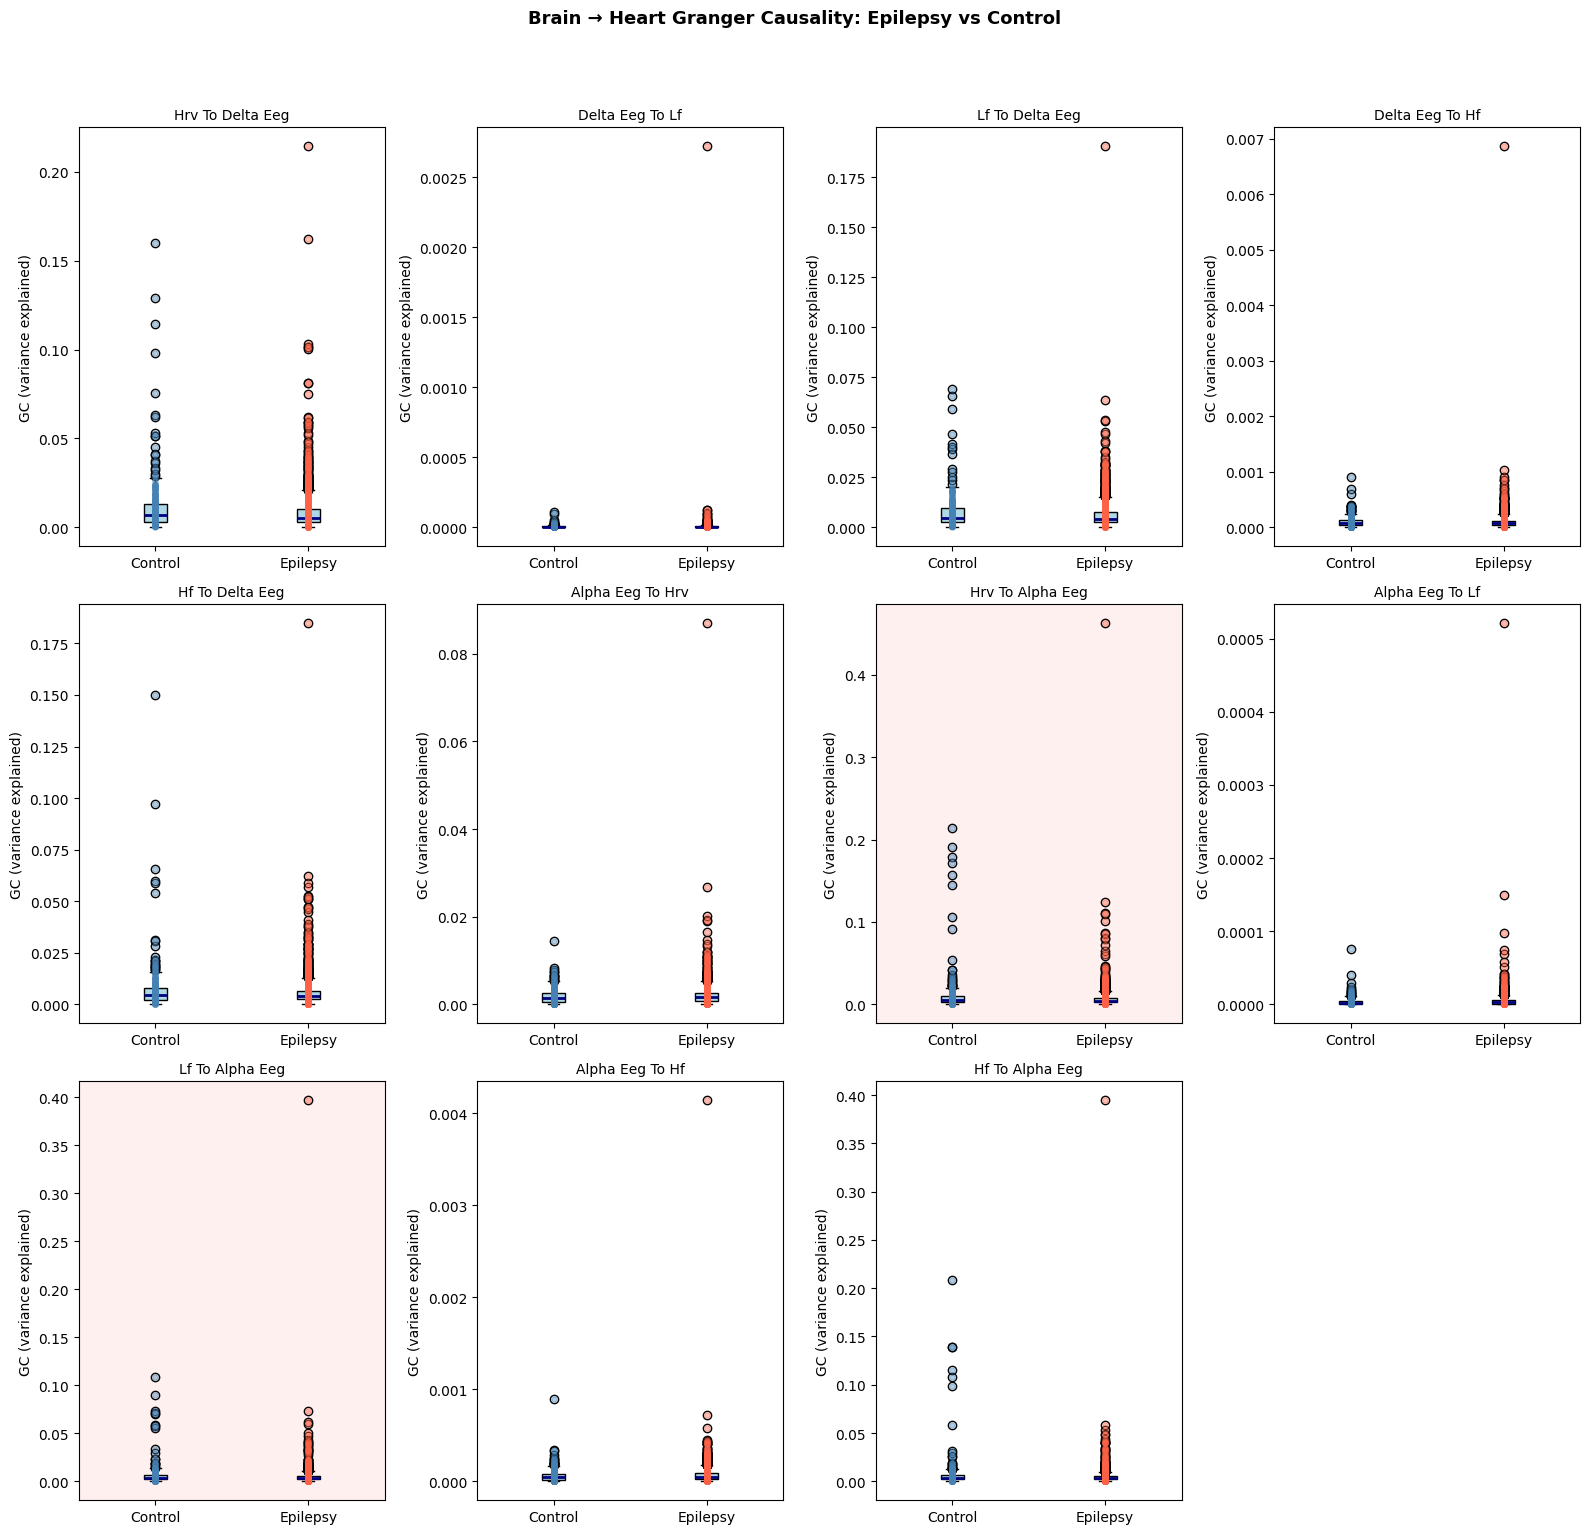

In [29]:
comparison_results = compare_groups(epilepsy_flat, control_flat)

plot_group_comparison(comparison_results)

In [30]:
def compare_groups_per_electrode(epilepsy_summaries, control_summaries):
    """
    Compare GC measures between groups for each electrode separately.
    
    epilepsy_summaries : list of dicts {electrode: {measure: value}}
    control_summaries  : same for control
    
    Returns: {electrode: {measure: {stat, p_raw, p_corrected, significant}}}
    """
    # Get electrodes and measures from first subject
    electrodes = list(epilepsy_summaries[0].keys())
    measures   = [k for k in epilepsy_summaries[0][electrodes[0]].keys()
                  if k != 'optimal_p']
    
    results = {}
    
    # Collect all p-values for FDR correction across all electrodes and measures
    all_p_values  = []
    all_keys      = []  # (electrode, measure) tuples
    
    for ch in electrodes:
        results[ch] = {}
        
        for measure in measures:
            # Extract value for this electrode and measure per subject
            epi_vals = np.array([s[ch][measure] for s in epilepsy_summaries
                                 if ch in s])
            ctrl_vals = np.array([s[ch][measure] for s in control_summaries
                                  if ch in s])
            
            if len(epi_vals) < 5 or len(ctrl_vals) < 5:
                continue
            
            # Check normality
            _, p_norm_epi  = normaltest(epi_vals)
            _, p_norm_ctrl = normaltest(ctrl_vals)
            both_normal = (p_norm_epi > 0.05) and (p_norm_ctrl > 0.05)
            
            if both_normal:
                stat, p = ttest_ind(epi_vals, ctrl_vals, equal_var=False)
                test = "Welch's t-test"
            else:
                stat, p = mannwhitneyu(epi_vals, ctrl_vals, 
                                       alternative='two-sided')
                test = "Mann-Whitney U"
            
            results[ch][measure] = {
                'epilepsy':  epi_vals,
                'control':   ctrl_vals,
                'stat':      stat,
                'p_raw':     p,
                'test':      test,
                'epi_median':  np.median(epi_vals),
                'ctrl_median': np.median(ctrl_vals),
                'effect':    np.median(epi_vals) - np.median(ctrl_vals)
            }
            
            all_p_values.append(p)
            all_keys.append((ch, measure))
    
    # FDR correction across all electrodes and measures simultaneously
    if all_p_values:
        _, p_corrected, _, _ = multipletests(all_p_values, method='fdr_bh')
        for (ch, measure), p_corr in zip(all_keys, p_corrected):
            results[ch][measure]['p_corrected'] = p_corr
            results[ch][measure]['significant'] = p_corr < 0.05
    
    return results


def print_significant_electrodes(per_electrode_results):
    """Print a summary of which electrodes are significant per measure."""
    electrodes = list(per_electrode_results.keys())
    measures   = [k for k in per_electrode_results[electrodes[0]].keys()
                  if k != 'optimal_p']
    
    print(f"{'Measure':<30} {'Significant electrodes (FDR p<0.05)'}")
    print("-" * 80)
    
    for measure in measures:
        sig_electrodes = []
        for ch in electrodes:
            if measure not in per_electrode_results[ch]:
                continue
            r = per_electrode_results[ch][measure]
            if r.get('significant', False):
                direction = '↑' if r['effect'] > 0 else '↓'
                sig_electrodes.append(f"{ch}{direction}")
        
        sig_str = ', '.join(sig_electrodes) if sig_electrodes else 'none'
        print(f"{measure:<30} {sig_str}")
    
    print("\n↑ = higher in epilepsy, ↓ = lower in epilepsy")


def plot_significant_electrodes(per_electrode_results, measure):
    """
    For a given measure, plot boxplots only for significant electrodes.
    """
    electrodes = list(per_electrode_results.keys())
    
    # Find significant electrodes for this measure
    sig_electrodes = [
        ch for ch in electrodes
        if measure in per_electrode_results[ch] and
        per_electrode_results[ch][measure].get('significant', False)
    ]
    
    if not sig_electrodes:
        print(f"No significant electrodes for {measure}")
        return
    
    n = len(sig_electrodes)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 5))
    if n == 1:
        axes = [axes]
    
    for ax, ch in zip(axes, sig_electrodes):
        r    = per_electrode_results[ch][measure]
        epi  = r['epilepsy']
        ctrl = r['control']
        p    = r['p_corrected']
        
        ax.boxplot([ctrl, epi],
                   labels=['Control', 'Epilepsy'],
                   patch_artist=True,
                   boxprops=dict(facecolor='lightblue'),
                   medianprops=dict(color='navy', linewidth=2))
        
        ax.scatter([1]*len(ctrl), ctrl, alpha=0.3, color='steelblue',
                   zorder=3, s=10)
        ax.scatter([2]*len(epi),  epi,  alpha=0.3, color='tomato',
                   zorder=3, s=10)
        
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*'
        y_max = np.percentile(np.concatenate([epi, ctrl]), 95) * 1.2
        ax.annotate(f'p={p:.3f}{sig}', xy=(1.5, y_max),
                    ha='center', fontsize=10)
        ax.set_ylim(bottom=0, top=y_max * 1.1)
        ax.set_title(f'Electrode {ch}', fontsize=11)
        ax.set_ylabel('GC (variance explained)')
    
    plt.suptitle(f'{measure.replace("_", " ").title()} — Significant Electrodes',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'sig_electrodes_{measure}.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_effect_size_per_electrode(per_electrode_results, measure):
    """
    Bar plot showing effect size (epilepsy median - control median)
    for all electrodes, highlighting significant ones.
    """
    electrodes = list(per_electrode_results.keys())
    
    effects = []
    colors  = []
    for ch in electrodes:
        if measure not in per_electrode_results[ch]:
            effects.append(0)
            colors.append('lightgray')
            continue
        r = per_electrode_results[ch][measure]
        effects.append(r['effect'])
        if r.get('significant', False):
            colors.append('tomato' if r['effect'] > 0 else 'steelblue')
        else:
            colors.append('lightgray')
    
    plt.figure(figsize=(12, 5))
    bars = plt.bar(electrodes, effects, color=colors)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.xlabel('Electrode')
    plt.ylabel('Effect size\n(epilepsy median − control median)')
    plt.title(f'{measure.replace("_", " ").title()}\n'
              f'Red/blue = significant (FDR corrected), gray = n.s.')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'effect_size_{measure}.png', dpi=150, bbox_inches='tight')
    plt.show()

Measure                        Significant electrodes (FDR p<0.05)
--------------------------------------------------------------------------------
delta_eeg_to_hrv               none
hrv_to_delta_eeg               none
delta_eeg_to_lf                none
lf_to_delta_eeg                none
delta_eeg_to_hf                none
hf_to_delta_eeg                none
alpha_eeg_to_hrv               none
hrv_to_alpha_eeg               none
alpha_eeg_to_lf                none
lf_to_alpha_eeg                none
alpha_eeg_to_hf                none
hf_to_alpha_eeg                none

↑ = higher in epilepsy, ↓ = lower in epilepsy
No significant electrodes for delta_eeg_to_hrv


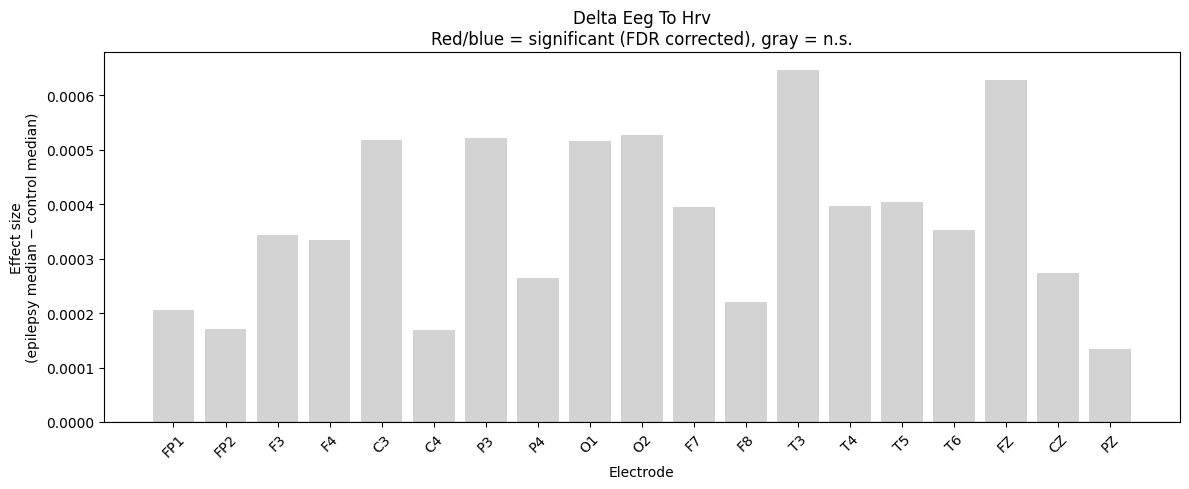

No significant electrodes for hrv_to_delta_eeg


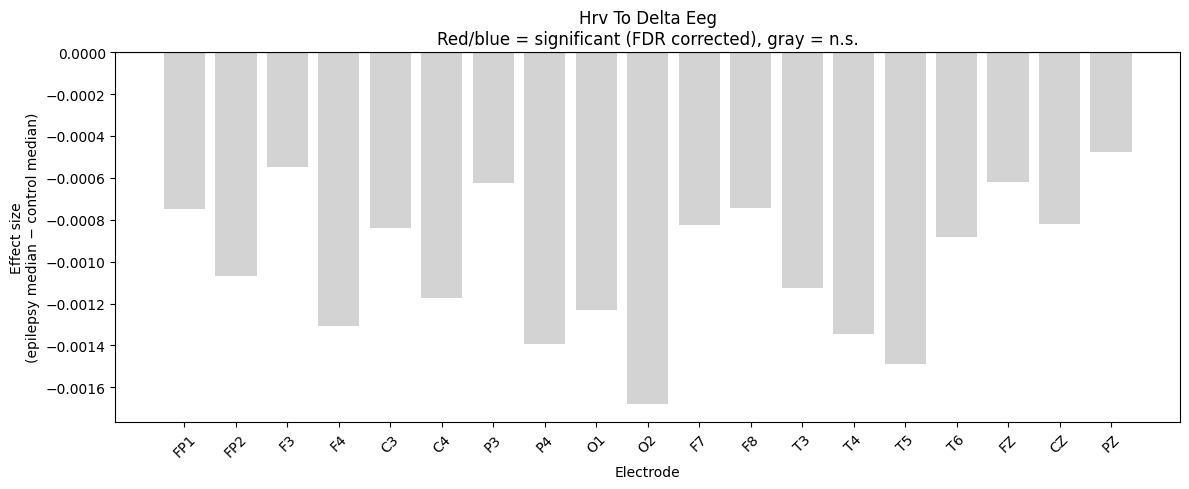

No significant electrodes for alpha_eeg_to_hrv


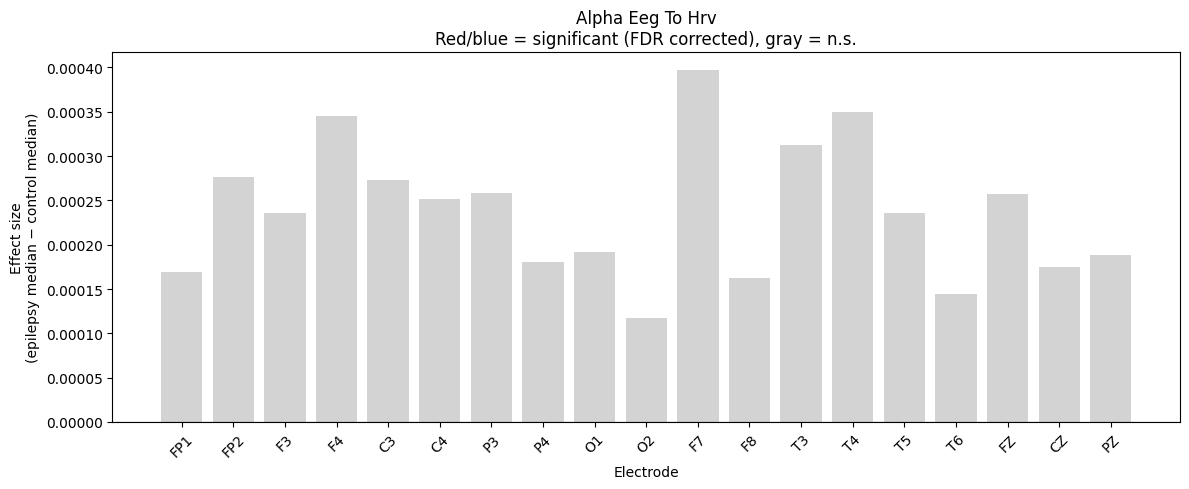

No significant electrodes for hrv_to_alpha_eeg


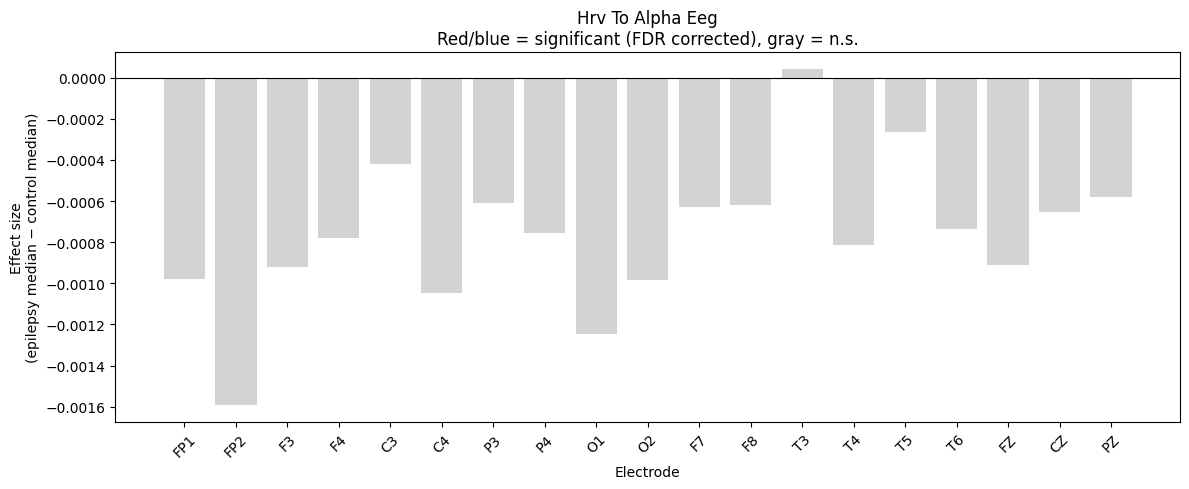

In [31]:
# Compute per-electrode group comparison
per_electrode_results = compare_groups_per_electrode(
    epilepsy_summaries, control_summaries
)

# Print summary table
print_significant_electrodes(per_electrode_results)

# Plot for each measure
measures = ['delta_eeg_to_hrv', 'hrv_to_delta_eeg',
            'alpha_eeg_to_hrv', 'hrv_to_alpha_eeg']

for measure in measures:
    plot_significant_electrodes(per_electrode_results, measure)
    plot_effect_size_per_electrode(per_electrode_results, measure)

In [32]:
pid_epilepsy_summaries

[{'T3_T4_delta': {'F_s1': 0.00031046238081226807,
   'F_s2': 0.0001903513733248624,
   'F_joint': 0.0005789875948406659,
   'unique_s1': 0.00012011100748740566,
   'unique_s2': 0.0,
   'redundant': 0.0001903513733248624,
   'synergistic': 0.0002685252140283978},
  'T3_T4_alpha': {'F_s1': 0.00020893534714572226,
   'F_s2': 0.00022327098569603632,
   'F_joint': 0.0004940385367475653,
   'unique_s1': 0.0,
   'unique_s2': 1.4335638550314056e-05,
   'redundant': 0.00020893534714572226,
   'synergistic': 0.00027076755105152894},
  'F7_F8_delta': {'F_s1': 0.00039454156681408004,
   'F_s2': 0.00032035424146846514,
   'F_joint': 0.0006798303926387056,
   'unique_s1': 7.41873253456149e-05,
   'unique_s2': 0.0,
   'redundant': 0.00032035424146846514,
   'synergistic': 0.00028528882582462556},
  'F7_F8_alpha': {'F_s1': 0.0001344379308860083,
   'F_s2': 0.0002536908048551001,
   'F_joint': 0.0003677250112733982,
   'unique_s1': 0.0,
   'unique_s2': 0.00011925287396909179,
   'redundant': 0.00013443

In [33]:
# PID measures to compare
pid_measures = [
    'unique_s1',    # unique from left electrode
    'unique_s2',    # unique from right electrode
    'redundant',    # shared between hemispheres
    'synergistic',  # joint effect
    'F_s1',         # bivariate GC left
    'F_s2',         # bivariate GC right
    'F_joint'       # joint GC
]

In [34]:


def compare_groups_per_pair(pid_epilepsy_summaries, pid_control_summaries):
    """
    Compare PID measures between groups for each electrode pair and band.
    
    pid_epilepsy_summaries : list of dicts {pair_key: {measure: value}}
    pid_control_summaries  : same for control
    
    Returns: {pair_key: {measure: {stat, p_raw, p_corrected, significant}}}
    """
    # Get pairs from first subject
    pairs    = list(pid_epilepsy_summaries[0].keys())
    measures = pid_measures

    results      = {}
    all_p_values = []
    all_keys     = []

    for pair in pairs:
        results[pair] = {}

        for measure in measures:
            epi_vals = np.array([s[pair][measure] for s in pid_epilepsy_summaries
                                 if pair in s and measure in s[pair]])
            ctrl_vals = np.array([s[pair][measure] for s in pid_control_summaries
                                  if pair in s and measure in s[pair]])

            if len(epi_vals) < 5 or len(ctrl_vals) < 5:
                continue

            # Normality check
            _, p_norm_epi  = normaltest(epi_vals)
            _, p_norm_ctrl = normaltest(ctrl_vals)
            both_normal = (p_norm_epi > 0.05) and (p_norm_ctrl > 0.05)

            if both_normal:
                stat, p = ttest_ind(epi_vals, ctrl_vals, equal_var=False)
                test = "Welch's t-test"
            else:
                stat, p = mannwhitneyu(epi_vals, ctrl_vals,
                                       alternative='two-sided')
                test = "Mann-Whitney U"

            results[pair][measure] = {
                'epilepsy':    epi_vals,
                'control':     ctrl_vals,
                'stat':        stat,
                'p_raw':       p,
                'test':        test,
                'epi_median':  np.median(epi_vals),
                'ctrl_median': np.median(ctrl_vals),
                'effect':      np.median(epi_vals) - np.median(ctrl_vals)
            }

            all_p_values.append(p)
            all_keys.append((pair, measure))

    # FDR correction across all pairs and measures
    if all_p_values:
        _, p_corrected, _, _ = multipletests(all_p_values, method='fdr_bh')
        for (pair, measure), p_corr in zip(all_keys, p_corrected):
            results[pair][measure]['p_corrected'] = p_corr
            results[pair][measure]['significant'] = p_corr < 0.05

    return results


def print_significant_pairs(per_pair_results):
    """Print which electrode pairs are significant per PID measure."""
    pairs    = list(per_pair_results.keys())
    measures = pid_measures

    print(f"{'Measure':<20} {'Significant pairs (FDR p<0.05)'}")
    print("-" * 80)

    for measure in measures:
        sig_pairs = []
        for pair in pairs:
            if measure not in per_pair_results[pair]:
                continue
            r = per_pair_results[pair][measure]
            if r.get('significant', False):
                direction = '↑' if r['effect'] > 0 else '↓'
                sig_pairs.append(f"{pair}{direction}")

        sig_str = ', '.join(sig_pairs) if sig_pairs else 'none'
        print(f"{measure:<20} {sig_str}")

    print("\n↑ = higher in epilepsy, ↓ = lower in epilepsy")


def plot_pid_comparison(per_pair_results, measure):
    """
    Boxplot for a given PID measure across all pairs,
    showing only significant ones.
    """
    pairs = list(per_pair_results.keys())

    sig_pairs = [p for p in pairs
                 if measure in per_pair_results[p] and
                 per_pair_results[p][measure].get('significant', False)]

    if not sig_pairs:
        print(f"No significant pairs for {measure}")
        return

    n = len(sig_pairs)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 5))
    if n == 1:
        axes = [axes]

    for ax, pair in zip(axes, sig_pairs):
        r    = per_pair_results[pair][measure]
        epi  = r['epilepsy']
        ctrl = r['control']
        p    = r['p_corrected']

        ax.boxplot([ctrl, epi],
                   labels=['Control', 'Epilepsy'],
                   patch_artist=True,
                   boxprops=dict(facecolor='lightblue'),
                   medianprops=dict(color='navy', linewidth=2))

        ax.scatter([1]*len(ctrl), ctrl, alpha=0.3, color='steelblue',
                   zorder=3, s=10)
        ax.scatter([2]*len(epi),  epi,  alpha=0.3, color='tomato',
                   zorder=3, s=10)

        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*'
        y_max = np.percentile(np.concatenate([epi, ctrl]), 95) * 1.2
        ax.annotate(f'p={p:.3f}{sig}', xy=(1.5, y_max),
                    ha='center', fontsize=10)
        ax.set_ylim(bottom=0, top=y_max * 1.1)
        ax.set_title(pair.replace('_', ' ').title(), fontsize=11)
        ax.set_ylabel('GC (variance explained)')

    plt.suptitle(f'PID — {measure.replace("_", " ").title()}'
                 f'\nSignificant electrode pairs only',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'pid_{measure}.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_pid_summary(per_pair_results):
    """
    Heatmap showing effect sizes across all pairs and PID measures.
    Significant cells are marked with *.
    """
    pairs    = list(per_pair_results.keys())
    measures = pid_measures

    # Build effect size matrix
    effect_matrix = np.zeros((len(measures), len(pairs)))
    sig_matrix    = np.zeros((len(measures), len(pairs)), dtype=bool)

    for j, pair in enumerate(pairs):
        for i, measure in enumerate(measures):
            if measure not in per_pair_results[pair]:
                continue
            r = per_pair_results[pair][measure]
            effect_matrix[i, j] = r['effect']
            sig_matrix[i, j]    = r.get('significant', False)

    # Normalize rows for visualization
    row_max = np.abs(effect_matrix).max(axis=1, keepdims=True)
    effect_norm = np.divide(effect_matrix, row_max,
                            where=row_max != 0, out=np.zeros_like(effect_matrix))

    fig, ax = plt.subplots(figsize=(len(pairs)*1.5 + 2, len(measures)*0.6 + 2))
    im = ax.imshow(effect_norm, cmap='RdBu_r', aspect='auto',
                   vmin=-1, vmax=1)

    # Add significance markers
    for i in range(len(measures)):
        for j in range(len(pairs)):
            if sig_matrix[i, j]:
                ax.text(j, i, '*', ha='center', va='center',
                        fontsize=14, fontweight='bold', color='black')

    ax.set_xticks(range(len(pairs)))
    ax.set_yticks(range(len(measures)))
    ax.set_xticklabels([p.replace('_', '\n') for p in pairs],
                       fontsize=9)
    ax.set_yticklabels(measures, fontsize=9)
    plt.colorbar(im, ax=ax, label='Normalized effect size\n(+ = higher in epilepsy)')
    ax.set_title('PID Measures: Epilepsy vs Control\n* = FDR significant',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('pid_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

Measure              Significant pairs (FDR p<0.05)
--------------------------------------------------------------------------------
unique_s1            none
unique_s2            none
redundant            none
synergistic          none
F_s1                 none
F_s2                 none
F_joint              none

↑ = higher in epilepsy, ↓ = lower in epilepsy


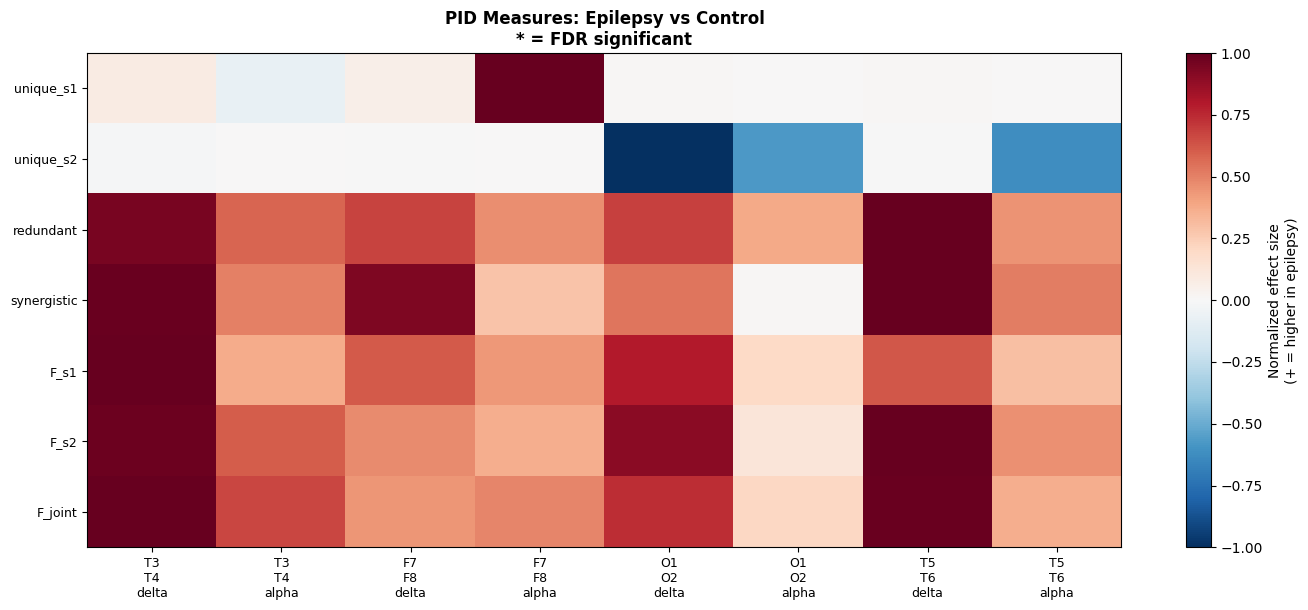

No significant pairs for unique_s1
No significant pairs for unique_s2
No significant pairs for redundant
No significant pairs for synergistic
No significant pairs for F_s1
No significant pairs for F_s2
No significant pairs for F_joint


In [35]:
# Compute group comparison per pair
per_pair_results = compare_groups_per_pair(
    pid_epilepsy_summaries, pid_control_summaries
)

# Summary table
print_significant_pairs(per_pair_results)

# Heatmap overview of all measures and pairs
plot_pid_summary(per_pair_results)

# Detailed boxplots for each PID measure
for measure in pid_measures:
    plot_pid_comparison(per_pair_results, measure)

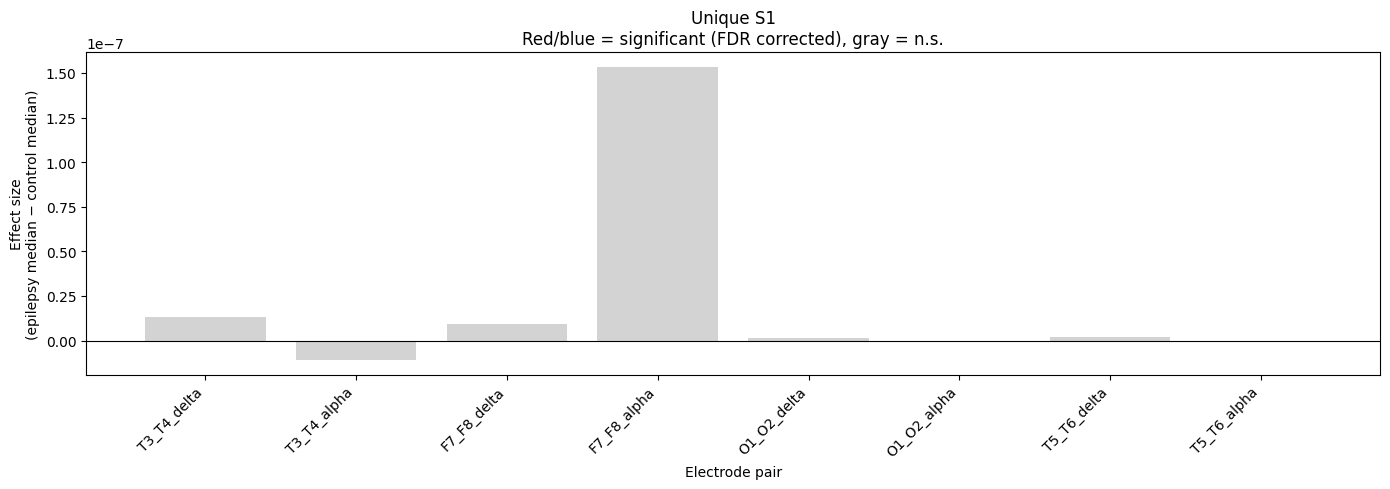

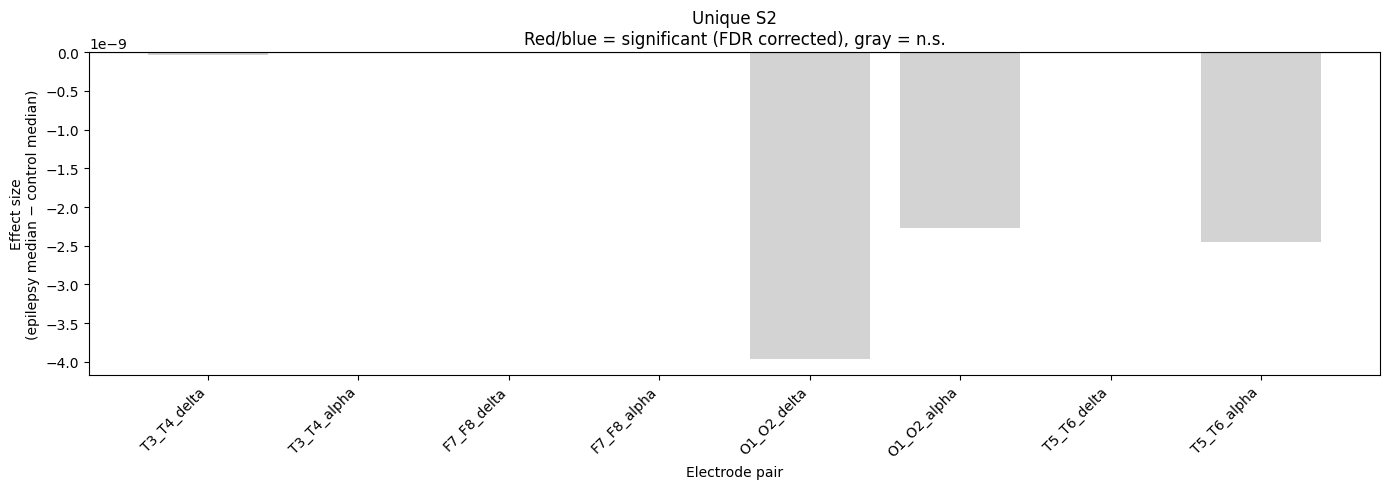

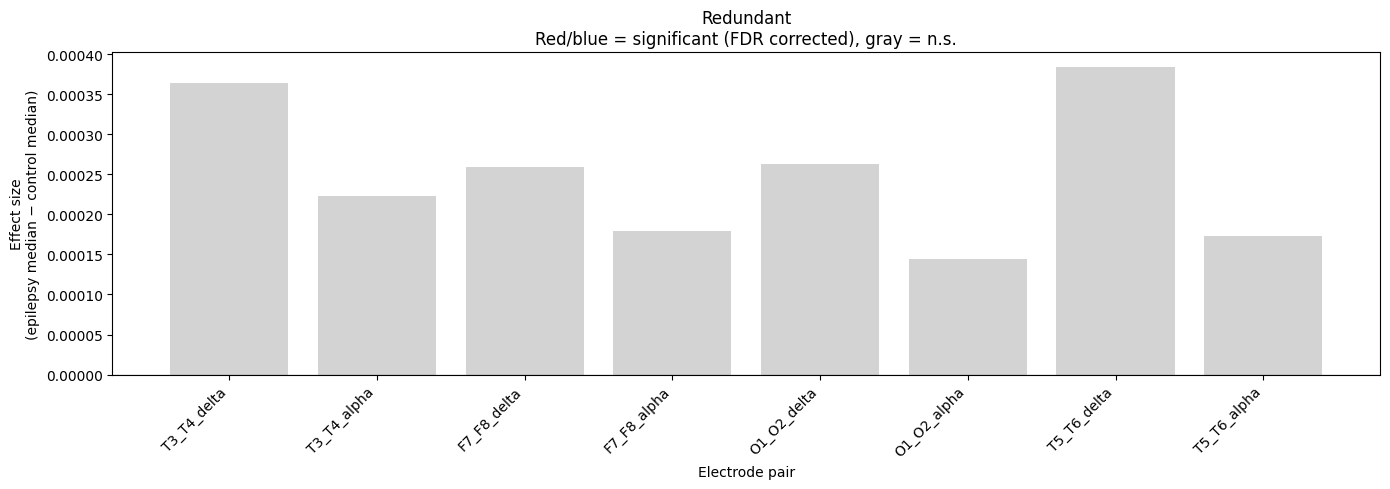

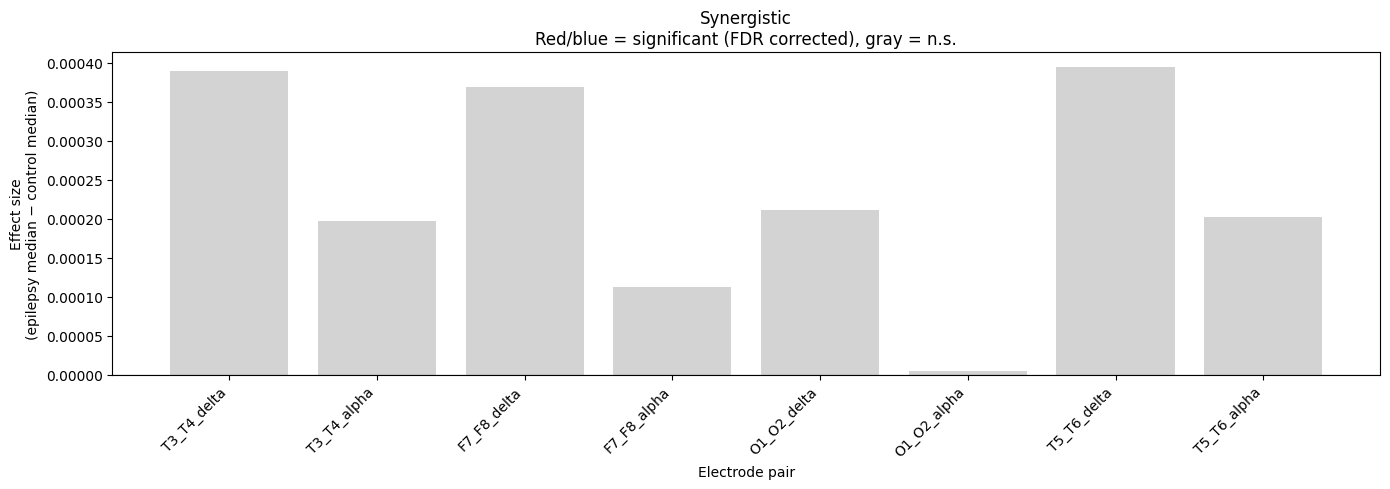

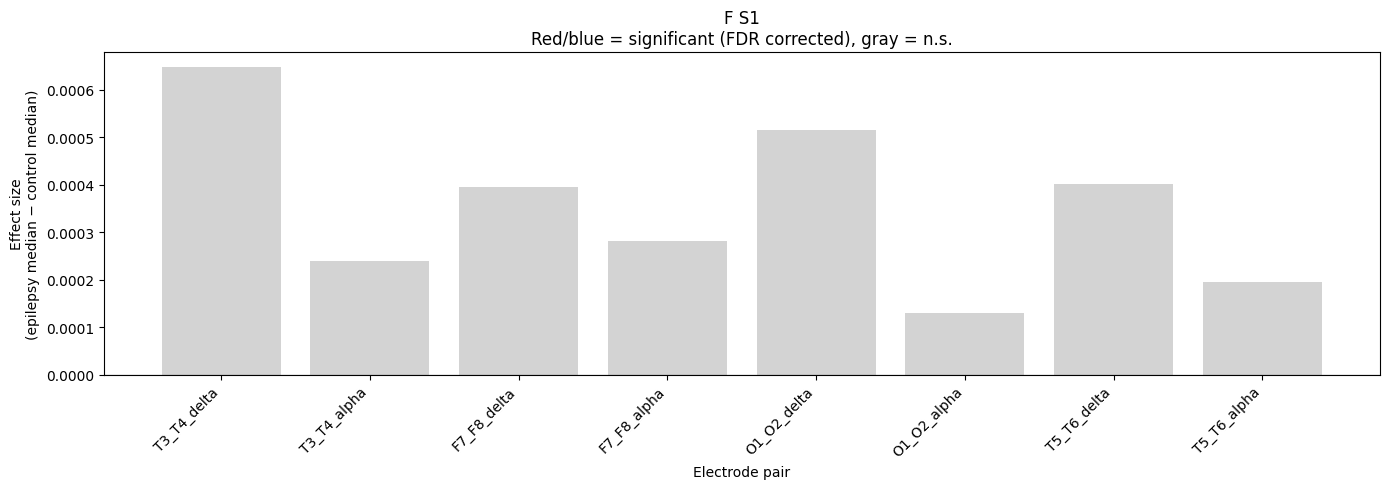

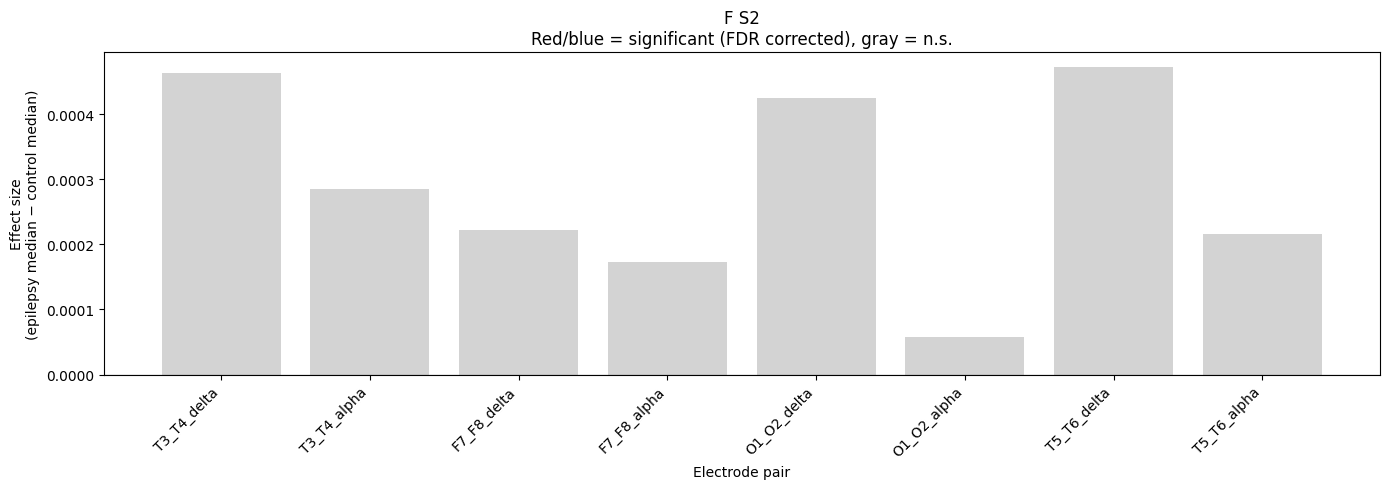

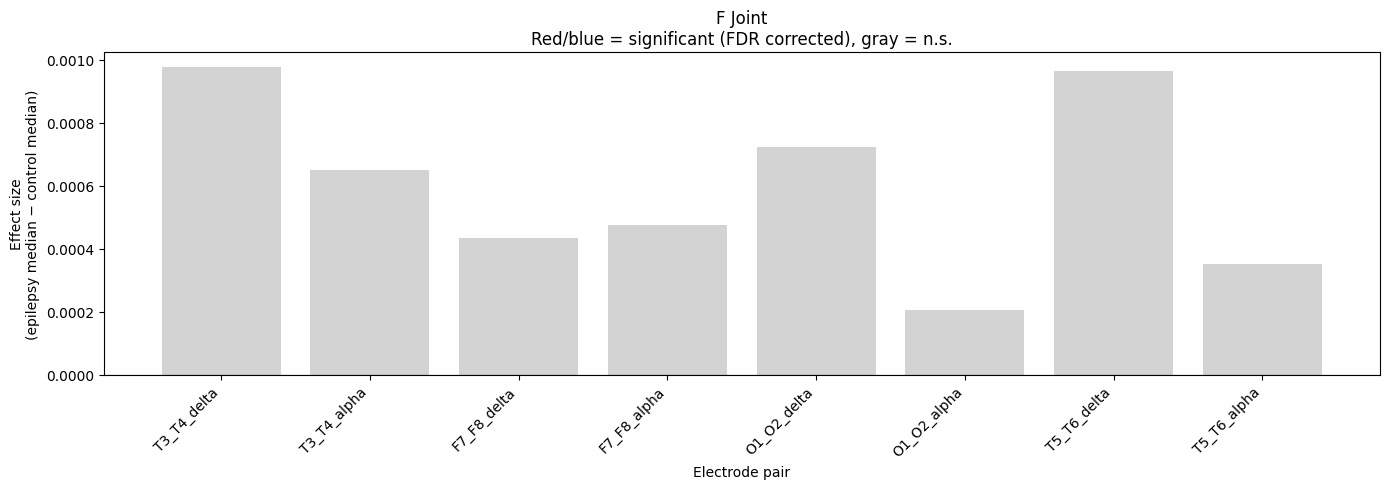

In [36]:
def plot_pid_effect_per_measure(per_pair_results):
    """
    For each PID measure, plot a bar chart showing effect size
    per electrode pair — same style as the GC electrode bar plots.
    """
    pairs    = list(per_pair_results.keys())
    measures = pid_measures

    for measure in measures:
        effects = []
        colors  = []

        for pair in pairs:
            if measure not in per_pair_results[pair]:
                effects.append(0)
                colors.append('lightgray')
                continue

            r = per_pair_results[pair][measure]
            effects.append(r['effect'])

            if r.get('significant', False):
                colors.append('tomato' if r['effect'] > 0 else 'steelblue')
            else:
                colors.append('lightgray')

        plt.figure(figsize=(len(pairs)*1.5 + 2, 5))
        plt.bar(pairs, effects, color=colors)
        plt.axhline(0, color='black', linewidth=0.8)
        plt.xlabel('Electrode pair')
        plt.ylabel('Effect size\n(epilepsy median − control median)')
        plt.title(f'{measure.replace("_", " ").title()}\n'
                  f'Red/blue = significant (FDR corrected), gray = n.s.')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(f'pid_{measure}.png', dpi=150, bbox_inches='tight')
        plt.show()

# Run
plot_pid_effect_per_measure(per_pair_results)